In [1]:
# ── Data Handling ──#
import pandas as pd
import numpy as np

# ── Visualization ──#
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine Learning ──#
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# ── Evaluation Metrics ───#
from sklearn.metrics import (accuracy_score, confusion_matrix,
classification_report, ConfusionMatrixDisplay)

# ── Model Saving ──#
import joblib

# ── Warninmgs ──#
import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv('farmer.csv')  
print("Dataset Shape:", df.shape)
print("Columns:", list(df.columns))
print("Total Crop Types:", df['label'].nunique())

Dataset Shape: (2200, 8)
Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']
Total Crop Types: 22


In [3]:

print("Missing Values:\n", df.isnull().sum())  

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [4]:
df.drop_duplicates(inplace=True)
print("Dataset Shape after removing duplicates:", df.shape)

Dataset Shape after removing duplicates: (2200, 8)


In [5]:
# Statistical summary of all numerical features
df.describe().round(2);

In [6]:
# Numerical vs Categorical features
print("Numerical Features: ", list(df.select_dtypes(exclude='object').columns))
print("Categorical features:", list(df.select_dtypes(include='object').columns))
print("\nCrop distribution:")
print(df['label'].value_counts())

Numerical Features:  ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
Categorical features: ['label']

Crop distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


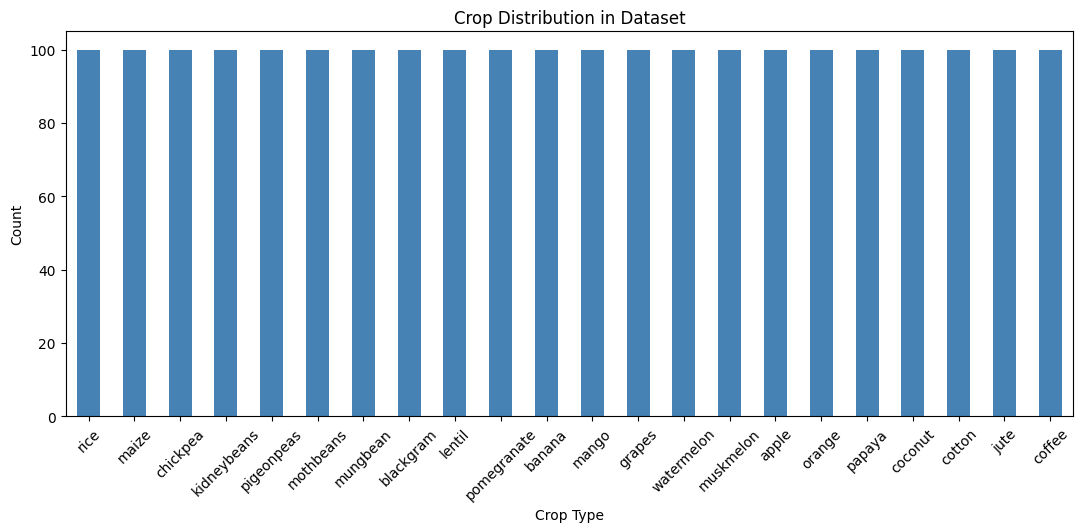

In [7]:
# 1. Crop distribution bar chart
plt.figure(figsize=(13, 5))
df['label'].value_counts().plot(kind='bar', color = 'steelblue')
plt.title('Crop Distribution in Dataset')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

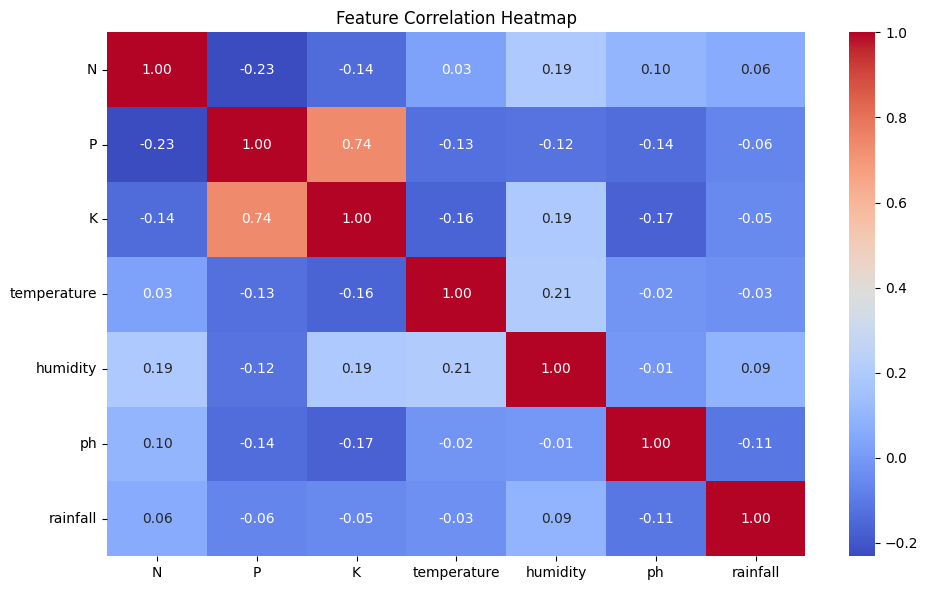

In [8]:
plt.figure(figsize=(10,6)) 
sns.heatmap(df.drop('label',axis=1).corr(), annot=True, cmap='coolwarm', fmt='.2f') 
plt.title("Feature Correlation Heatmap") 
plt.tight_layout() 
plt.show()

In [9]:
# Encode target: 'rice' → 0, 'wheat' → 1, etc.
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])
print("Encoded classes:", dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: {'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}


In [10]:
# Label Encoding — crop names ko numbers mein badalna
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])  # e.g., 'rice' → 0, 'wheat' → 1

In [11]:
X = df.drop('label', axis=1)  # 7 input features
y = df['label']                # 1 output (crop number)
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 1760 | Test: 440


In [13]:
models = {
    'Random Forest' : RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree' : DecisionTreeClassifier(random_state=42),
    'Naive Bayes'   : GaussianNB()
}

results = {}
for name, m in models.items():
    m.fit(X_train, y_train)
    train_acc = m.score(X_train, y_train)
    test_acc  = m.score(X_test,  y_test)
    results[name] = test_acc
    print(f"{name:<20} Train: {train_acc:.4f} | Test: {test_acc:.4f}")

best = max(results, key=results.get)
print(f"\n🏆 Best: {best} ({results[best]*100:.2f}%)")


Random Forest        Train: 1.0000 | Test: 0.9932
Decision Tree        Train: 1.0000 | Test: 0.9864
Naive Bayes          Train: 0.9949 | Test: 0.9955

🏆 Best: Naive Bayes (99.55%)


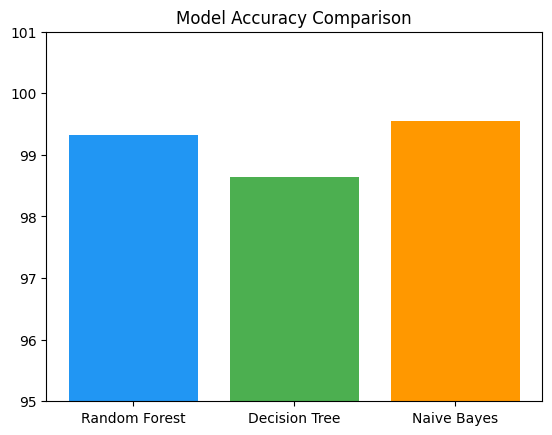

In [14]:
plt.bar(results.keys(), [v*100 for v in results.values()],
        color=['#2196F3','#4CAF50','#FF9800'])
plt.title("Model Accuracy Comparison")
plt.ylim(95, 101)
plt.show()

In [16]:
# Random Forest final choose kiya (industry standard, overfitting resistant)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
crop_names = [str(c) for c in le.classes_]
print(classification_report(y_test, y_pred, target_names=crop_names))

Accuracy: 0.9931818181818182
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00      1.00      1.00        1

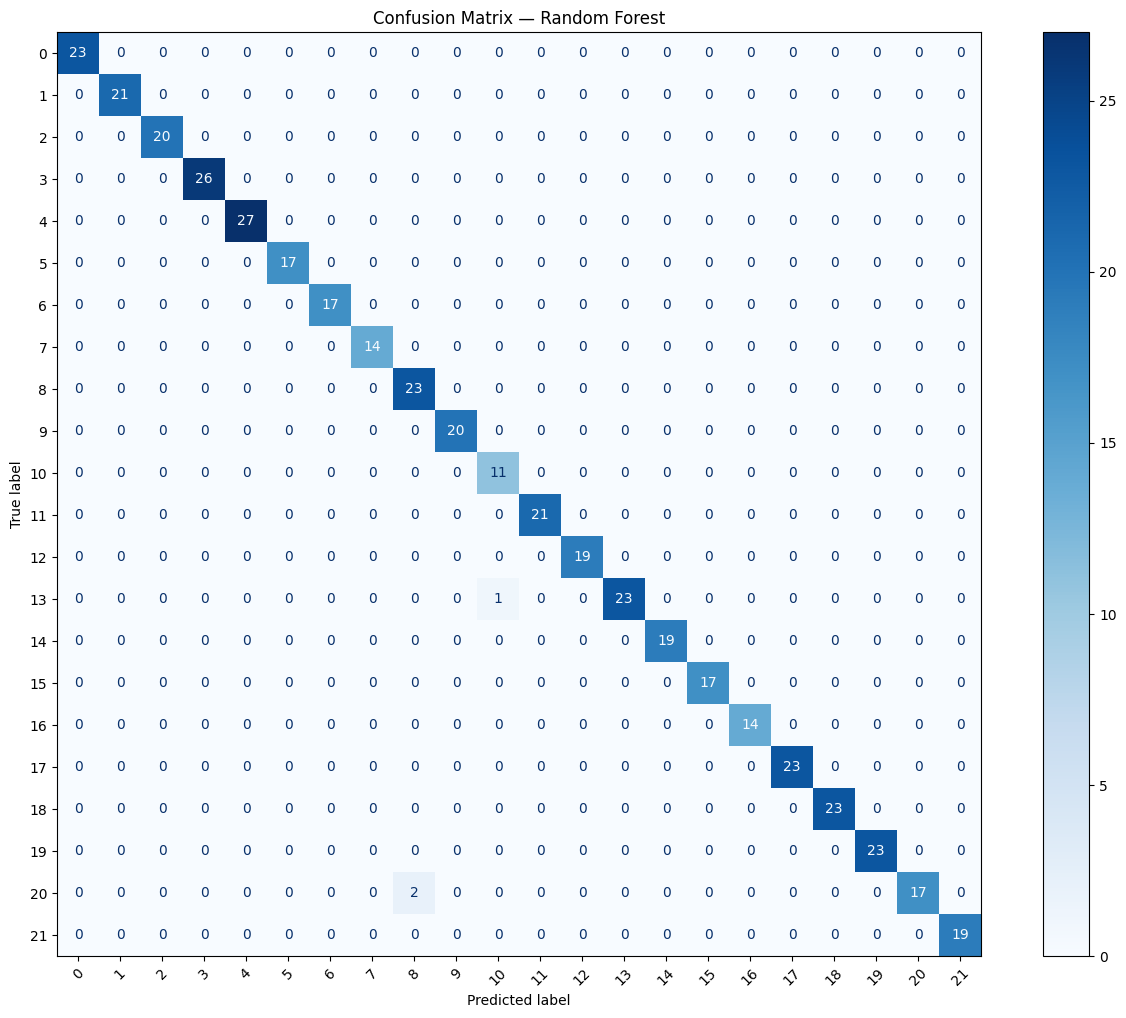

In [17]:
fig, ax = plt.subplots(figsize=(16,12))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=le.classes_,
    xticks_rotation=45, ax=ax, cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()

In [18]:
cv_scores = cross_val_score(model, X, y, cv=5)
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy: 0.9945 ± 0.0034


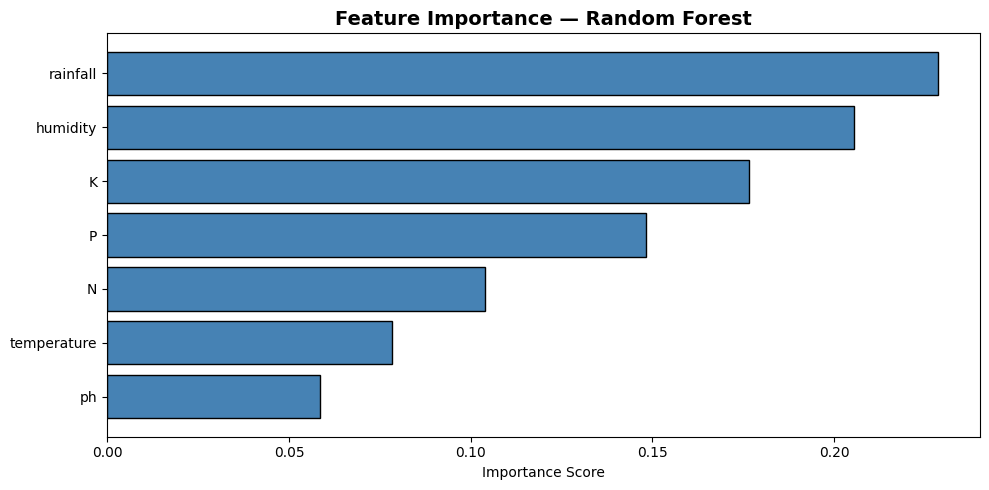


Feature Ranking:
  rainfall    : 0.2287  ███████████
  humidity    : 0.2054  ██████████
  K           : 0.1765  ████████
  P           : 0.1483  ███████
  N           : 0.1041  █████
  temperature : 0.0783  ███
  ph          : 0.0586  ██


In [34]:
importances = model.feature_importances_
features    = X.columns
indices     = importances.argsort()  # ascending sort

# ── Bar Chart ──────────────────────────────────
plt.figure(figsize=(10, 5))
plt.barh(range(len(indices)), importances[indices],
         color='steelblue', edgecolor='black')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance Score')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Text Output ────────────────────────────────
print("\nFeature Ranking:")
for feat, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"  {feat:12s}: {imp:.4f}  {'█' * int(imp*50)}")

In [ ]:
joblib.dump(model, 'crop_recommendation_model.pkl')
joblib.dump(le,    'crop_label_encoder.pkl')
print("Model saved!")

In [36]:
# Training aur Testing data mein split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [38]:
y_pred = model.predict(X_test)

In [39]:
y_pred = model.predict(X_test)

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9931818181818182
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        20
           3       1.00      1.00      1.00        26
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        17
           6       1.00      1.00      1.00        17
           7       1.00      1.00      1.00        14
           8       0.92      1.00      0.96        23
           9       1.00      1.00      1.00        20
          10       0.92      1.00      0.96        11
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        19
          13       1.00      0.96      0.98        24
          14       1.00      1.00      1.00        19
          15       1.00      1.00      1.00        17
          16       1.00     

In [41]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((1760, 7), (440, 7), (1760,), (440,))

In [42]:
y_test

1451    15
1334    21
1761    17
1735    17
1576     0
        ..
59      20
71      20
1908     6
1958     6
482     18
Name: label, Length: 440, dtype: int64

In [43]:
X_test

,N,P,K,temperature,humidity,ph,rainfall
1451,101,17,47,29.494014,94.729813,6.185053,26.308209
1334,98,8,51,26.179346,86.522581,6.259336,49.430510
1761,59,62,49,43.360515,93.351916,6.941497,114.778071
1735,44,60,55,34.280461,90.555616,6.825371,98.540477
1576,30,137,200,22.914300,90.704756,5.603413,118.604465
...,...,...,...,...,...,...,...
59,99,55,35,21.723831,80.238990,6.501698,277.962619
71,67,45,38,22.727910,82.170688,7.300411,260.887506
1908,121,47,16,23.605640,79.295731,7.723240,72.498009
1958,116,52,19,22.942767,75.371706,6.114526,67.080226


In [44]:
import joblib

# ✅ Save the model
joblib.dump(model, "model_of_farmer.pkl")  # Use .pkl as a standard extension
joblib.dump(le, "crop_label_encoder.pkl")   # labelencoder object
# ✅ Load the model
loaded_model = joblib.load("model_of_farmer.pkl")

predictions = loaded_model.predict(X_test)
print("Predictions:", predictions)

Predictions: [15 21 17 17  0 12  0 13 14 10  2  4 19  8  4 19  0 11 17 15  5 17 16 17
  3  8 14 16 18 20 19 13  8 10  8  2  8  3  3  9 17 12  2 11 14 11 18  4
 15 11  2  5  7 14  5  9  6  0  1  2 21  4 10 16 17 18 16 20 15 18 15  4
  8  1  2 17  1  6 21 16  5  3 20 13 16 12  5 13  2 19 11 13  6 17 18 13
  9  5  2 10  4 20 16 15 21  9 21  1 18 13  1  8  6 19 18  3 11  4 19 20
 18  7  2  4  3  2  4 11  1 13  1  9 19  3  4 16 18  1  1  0  9 15 14 13
  4 11  0  4  9 13 14 10 21 14 18 18 18  9 11  8  3  0 16  6 20  4  7 10
 21  7  7  2 19  3  4 11 10  7 21  8  5  5  9  8 13  9  1  9  4 17 17 14
 12 19 21  9 11  0  2  3  7  7  1  6 20 19 14  1  8 14 11  3  3  3  0 20
  9 17  5  2  9 12 12  4 17  0  3 19  3 15  0 15 15 12 12  6  4 19 20 15
  5 17 13 11 12 15 18 14  5  7  4  6 18 20  0 19  5  3  6  8 12  1 17  0
  3 20 18 13 14  8 19  7 13  8 11  4 11  3  1  8  4  8 12 15  0  1 18  2
 16  3 21  1  0  3  5 18 16  0  4 17 21 13 17  3 19  3 17 10  0 19  3 12
  3 19 21  9 14 15 21  9 15 12  8  2  

In [45]:
# Decision Tree Classifier

dt = DecisionTreeClassifier(random_state=42)  # Decision Tree model banaya
dt.fit(X_train, y_train)  # Training data se model train kiya

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [46]:
# Decision Tree Classifier
 
# Test data pe prediction
y_pred_dt = dt.predict(X_test)


In [47]:
# Decision Tree Classifier

# Model evaluation (accuracy aur confusion matrix)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))  # actual vs predicted
print(classification_report(y_test, y_pred_dt))  # precision, recall, f1-score

Decision Tree Accuracy: 0.9863636363636363
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 22  0  0  0  0  0  0  0  0  0  0  0  1  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  1  0  0  0  0  0  0  0  1  0  0 22  0  0  0  0  0  

TypeError: can only concatenate str (not "numpy.int64") to str

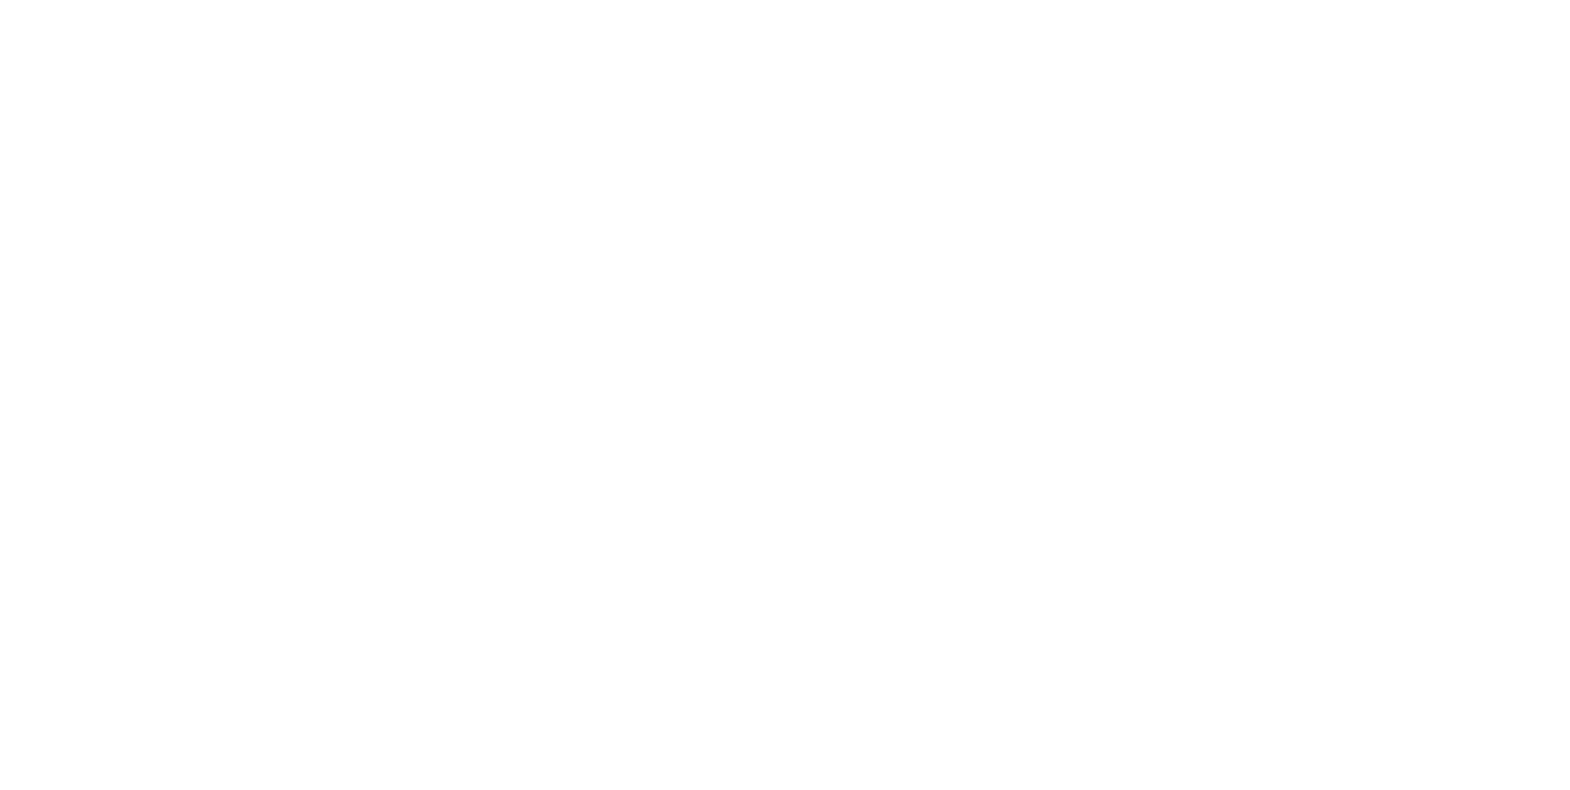

In [48]:
# Decision Tree Visualization

plt.figure(figsize=(20,10))  # graph ka size set kiya
plot_tree(dt, feature_names=X.columns, class_names=le.classes_, filled=True)  # tree draw kiya
plt.title("Decision Tree Visualization")  # title diya
plt.show()  # graph display kiya

In [ ]:
# Random Forest Classifier

rf = RandomForestClassifier(n_estimators=150,random_state=42,max_depth=3,min_samples_leaf=2)  # Random Forest model banaya
rf.fit(X_train, y_train)  # model train kiya

,n_estimators,150
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Random Forest Classifier

# Test pe prediction
y_pred_rf = rf.predict(X_test)

In [ ]:
# Random Forest Classifier

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8613636363636363
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  4  0  0  1  0  0  0  0  0  0  0  0  0  0  0 18  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  3  0  0  0  0 18  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  7  0  0  0  0  0  0  0 15  0  2  0  0  0  0  0  0  

c:\Users\welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [ ]:
# Features Importance (Random Forest)

importances = rf.feature_importances_  # har feature ka importance score
features = X.columns  # feature names
indices = np.argsort(importances)  # sorting for better visualization

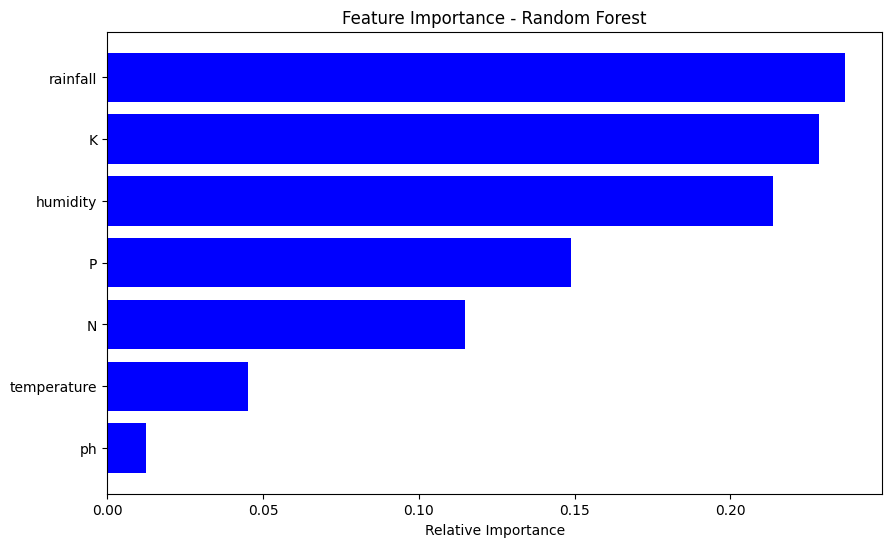

In [ ]:
# Feature Importance Bar Chart
plt.figure(figsize=(10,6))
plt.title("Feature Importance - Random Forest")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])  # feature names on Y axis
plt.xlabel('Relative Importance')  # X-axis label
plt.show()

In [ ]:
rf.score(X_test,y_test)

0.8613636363636363

In [ ]:
rf.score(X_train,y_train)

0.8892045454545454

In [ ]:
# Step 4: Train Naive Bayes model
model = GaussianNB()  # Gaussian Naive Bayes (continuous data ke liye)
model.fit(X_train, y_train)

c:\Users\welcome\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)


,priors,None
,var_smoothing,1e-09


In [ ]:
y_pred = model.predict(X_test)


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))  # Accuracy
print(confusion_matrix(y_test, y_pred))             # Confusion matrix
print(classification_report(y_test, y_pred))        # Precision, recall, f1


Accuracy: 0.9954545454545455
[[23  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0 20  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 26  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 27  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 17  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 14  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 23  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0 20  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 11  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0 21  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0 19  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0]
 [ 0 

In [ ]:
model.score(X_test,y_test)

0.9954545454545455

In [ ]:
model.score(X_train,y_train)

0.9948863636363636